In [15]:
import pandas as pd


In [16]:
df = pd.read_csv("../results/experiments.csv")
df_95 = df[df['sequence_length']=='95']

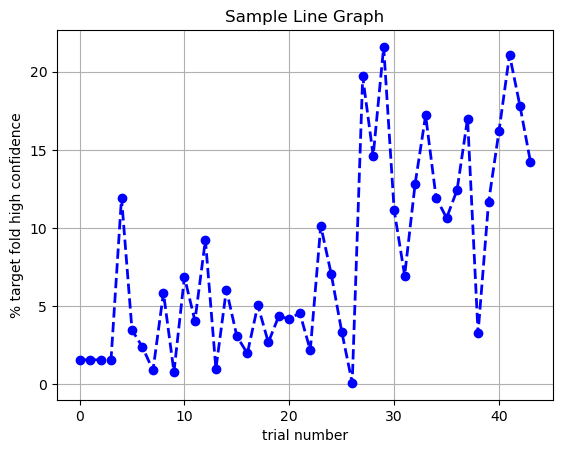

In [17]:
import matplotlib.pyplot as plt

# 1. Define the data points
df_95 = df_95.reset_index()
x = df_95.index  # Reset index to get a range for x-axis
y = df_95['pct_target_fold_high_conf']

# 2. Create the line plot with custom styles
plt.plot(x, y, color='blue', linestyle='--', marker='o', linewidth=2)

# 3. Add titles and labels for clarity
plt.title("Sample Line Graph")
plt.xlabel("trial number")
plt.ylabel("% target fold high confidence")

# 4. Add a background grid (optional)
plt.grid(True)

# 5. Display the window
plt.show()

In [25]:
df_all = pd.read_csv("/Users/mipopovic/Desktop/protein-design/results/all_designs.csv")

In [26]:
df_all.shape

(11661, 8)

In [27]:
df_all = df_all.drop_duplicates(subset=['Sequence'])
df_all.shape

(11494, 8)

In [28]:
df_all.head()

,run_id,Sequence,CATHe_Prediction_Probability,CATHe_Predicted_SFAM,seq_len,temperature,global_score,seq_recovery
0,20260617_161625_2ef11a,AASVASVSLSPGPTVSRADPLKVTVTLTPATASGTVTGEVLSTDGT...,0.810426,2.60.40.1910,95,0.3,1.0356,0.1053
1,20260617_161625_2ef11a,GEPVVKENGNLILKTDKSVYSLSEKLNVYYKDKNKNKITLQLLSSD...,0.797498,2.60.40.1910,95,0.3,1.1378,0.0105
2,20260617_161625_2ef11a,SATVASVSLEPGPVVRREEPLVVHVTLTPPGAEGTVRYELLSEDGQ...,0.784257,2.60.40.1910,95,0.3,1.0710,0.0737
3,20260617_161625_2ef11a,MKVKVNKQLILECSVEPQTVTDKTKLYIKLKEDAKAKISILKPDGT...,0.764260,2.60.40.3050,95,0.3,1.1895,0.0421
4,20260617_161625_2ef11a,AEEEQKKKLITLAEAEPKEVENKTKLIVEVKEDANVDIEIKSPDGK...,0.747947,2.60.40.3050,95,0.3,1.1914,0.0526


In [29]:
df_all.sort_values(by='CATHe_Prediction_Probability', ascending=False, inplace=True)

In [62]:
df_high_conf = df_all[df_all['CATHe_Prediction_Probability'] > 0.98]
df_high_conf.shape

(280, 8)

In [45]:
df_high_conf['seq_len'].unique()

array([ 95, 100,  90, 110])

In [46]:
df_high_conf['CATHe_Predicted_SFAM'].unique()

array(['2.60.40.4100', '2.60.40.1910', '2.60.40.1670', '2.60.40.3050',
       '2.60.40.10', '2.60.40.1170', '2.60.40.2370', '2.60.40.4030',
       '2.60.40.1290', '2.60.40.200'], dtype=object)

In [63]:
# df_best = df_high_conf.head(200)
df_best = df_high_conf

In [64]:
df_best.shape

(280, 8)

In [65]:
df_best['CATHe_Predicted_SFAM'].unique()

array(['2.60.40.4100', '2.60.40.1910', '2.60.40.1670', '2.60.40.3050',
       '2.60.40.10', '2.60.40.1170', '2.60.40.2370', '2.60.40.4030',
       '2.60.40.1290', '2.60.40.200'], dtype=object)

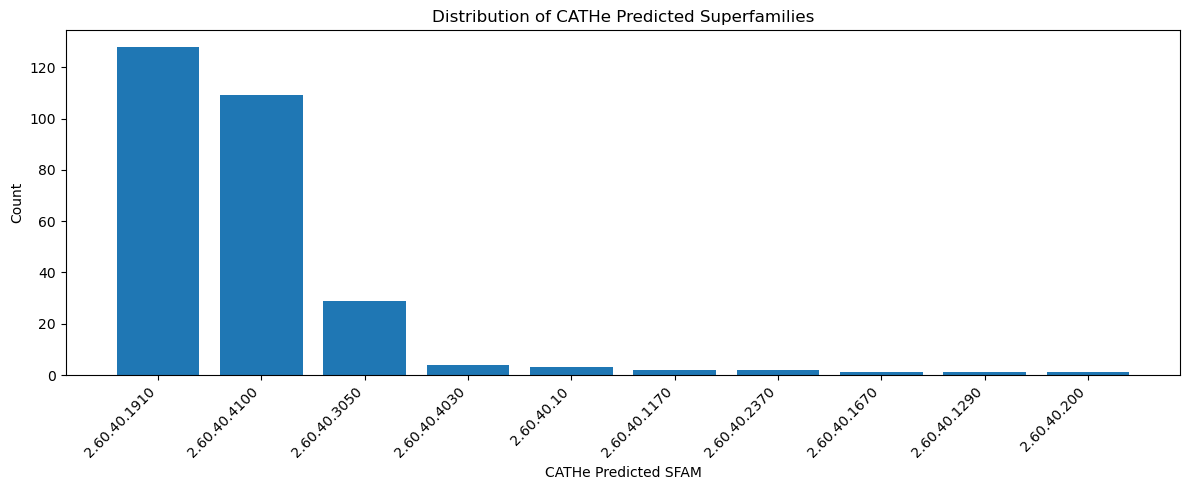

In [66]:
counts = df_best['CATHe_Predicted_SFAM'].value_counts()

plt.figure(figsize=(12, 5))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('CATHe Predicted SFAM')
plt.ylabel('Count')
plt.title('Distribution of CATHe Predicted Superfamilies')
plt.tight_layout()
plt.show()

In [67]:
df_best.reset_index(drop=True, inplace=True)

In [68]:
df_best.to_csv("/Users/mipopovic/Desktop/protein-design/results/best_designs.csv", index=False)

In [69]:
with open('/Users/mipopovic/Desktop/protein-design/results/df_best.fasta', 'w') as f:
    for idx, row in df_best.iterrows():
        f.write(f'>seq_{idx}\n{row["Sequence"]}\n')